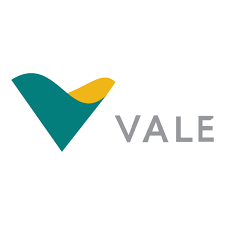

# <span style="color: #007E7A;">PROGRAMA DESENVOLVER</span>

## Perguntas Analíticas — Desafio Antecipação de Alertas Críticos

##### P1 — Pergunta Principal (Modelagem Preditiva)
**Quais equipamentos têm maior risco de gerar um alerta Don't Go nas próximas 4 horas, considerando o padrão atual de operação?**

---

### P2 — Perfil de Equipamentos (EDA)
**Qual é o perfil dos equipamentos que mais geram alertas Don't Go — considerando TAG, frota, modelo e horas de operação?**

---

### P3 — Padrões Temporais (EDA)
**Alertas críticos se concentram em determinados turnos, dias da semana ou períodos do mês?**

---

### P4 — Comportamento do Operador (EDA)
**O comportamento do operador tem correlação com a frequência de alertas Don't Go em um mesmo equipamento?**

---

### P5 — Impacto Operacional (Avaliação)
**Dado o risco previsto de alerta, qual seria a recomendação de ação: continuar operação, acionar manutenção preventiva agendada ou parada imediata?**

---

### P6 — Priorização da Manutenção (Resultados)
**Como priorizar a fila de inspeção da manutenção com base no score de risco de cada equipamento?**

#### Bibliotecas 

In [13]:
%pip install pyarrow
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd

In [15]:
df_apontamentos = pd.read_parquet(r"projeto-desenvolver-vale\datasets\apontamentos\desenvolver_apontamentos.parquet", engine="fastparquet")

In [16]:
df_apontamentos.head()

,Id,Inicio,Fim,Tag,Frota,Tipo,Classe
0,23462554,2025-01-04 19:12:54,2025-01-04 19:40:29,CA65789,793-D 2S,Caminhao,Operando
1,23462555,2025-01-04 19:12:28,2025-01-04 19:38:15,CA65908,793-D 3S,Caminhao,Operando
2,23462556,2025-01-04 19:14:07,2025-01-04 19:18:29,CA65915,793-D 4S,Caminhao,Parado
3,23462759,2025-01-04 19:20:36,2025-01-04 19:27:44,CA5926,793-D 5S,Caminhao,Parado
4,23462762,2025-01-04 19:18:29,2025-01-04 19:23:51,CA65915,793-D 4S,Caminhao,Operando


In [17]:
df_telemetria_jan = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_jan.parquet", engine="fastparquet")

df_telemetria_fev = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_feb.parquet", engine="fastparquet")

df_telemetria_mar = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_mar.parquet", engine="fastparquet")

df_telemetria_abr = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_abr.parquet", engine="fastparquet")

df_telemetria_mai = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_may.parquet", engine="fastparquet")

df_telemetria_jun = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_jun.parquet", engine="fastparquet")

In [18]:
lista_dfs = [df_telemetria_jan, df_telemetria_fev, df_telemetria_mar, df_telemetria_abr, df_telemetria_mai, df_telemetria_jun]

In [19]:
df_telemetria_total = pd.concat(lista_dfs, ignore_index=True)

In [20]:
df_telemetria_total.head(5)

,Id_Eventos_Telemetria,Data_Evento,Inicio_Turno,Fim_Turno,Dia,Localidade,TAG,Tag_Frota,Tipo,Nome_Operador_Anon,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Classe,Is_Dont_Go
0,9372078,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,NULL,0
1,9372079,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,NULL,0
2,9372097,2025-01-01 00:02:20.280,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",NULL,0
3,9372111,2025-01-01 00:02:59.077,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",NULL,0
4,9372120,2025-01-01 00:03:37.963,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",NULL,0


In [27]:
colunas_telemetria = list(df_telemetria_total.columns)
colunas_telemetria

['Id_Eventos_Telemetria',
 'Data_Evento',
 'Inicio_Turno',
 'Fim_Turno',
 'Dia',
 'Localidade',
 'TAG',
 'Tag_Frota',
 'Tipo',
 'Nome_Operador_Anon',
 'Matricula_Operador_Hash',
 'Id_Alarme',
 'Alarme',
 'Id_Criticidade',
 'Criticidade',
 'Valor',
 'Classe',
 'Is_Dont_Go']

In [28]:
colunas_apontamentos = list(df_apontamentos.columns)
colunas_apontamentos   

['Id', 'Inicio', 'Fim', 'Tag', 'Frota', 'Tipo', 'Classe']

In [30]:
df_apontamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377907 entries, 0 to 377906
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Id      377907 non-null  int64         
 1   Inicio  377907 non-null  datetime64[ns]
 2   Fim     377907 non-null  datetime64[ns]
 3   Tag     377907 non-null  object        
 4   Frota   377907 non-null  object        
 5   Tipo    377907 non-null  object        
 6   Classe  377907 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 20.2+ MB


In [21]:
df_telemetria_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37164054 entries, 0 to 37164053
Data columns (total 18 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   Id_Eventos_Telemetria    int64         
 1   Data_Evento              datetime64[us]
 2   Inicio_Turno             object        
 3   Fim_Turno                object        
 4   Dia                      int64         
 5   Localidade               object        
 6   TAG                      object        
 7   Tag_Frota                object        
 8   Tipo                     object        
 9   Nome_Operador_Anon       object        
 10  Matricula_Operador_Hash  object        
 11  Id_Alarme                int64         
 12  Alarme                   object        
 13  Id_Criticidade           int64         
 14  Criticidade              object        
 15  Valor                    object        
 16  Classe                   object        
 17  Is_Dont_Go               

In [22]:
print(df_apontamentos.isnull().sum())

Id        0
Inicio    0
Fim       0
Tag       0
Frota     0
Tipo      0
Classe    0
dtype: int64


In [23]:
print(df_telemetria_total.isnull().sum())

Id_Eventos_Telemetria      0
Data_Evento                0
Inicio_Turno               0
Fim_Turno                  0
Dia                        0
Localidade                 0
TAG                        0
Tag_Frota                  0
Tipo                       0
Nome_Operador_Anon         0
Matricula_Operador_Hash    0
Id_Alarme                  0
Alarme                     0
Id_Criticidade             0
Criticidade                0
Valor                      0
Classe                     0
Is_Dont_Go                 0
dtype: int64


In [25]:
colunas = list(df_telemetria_total.columns)
colunas

['Id_Eventos_Telemetria',
 'Data_Evento',
 'Inicio_Turno',
 'Fim_Turno',
 'Dia',
 'Localidade',
 'TAG',
 'Tag_Frota',
 'Tipo',
 'Nome_Operador_Anon',
 'Matricula_Operador_Hash',
 'Id_Alarme',
 'Alarme',
 'Id_Criticidade',
 'Criticidade',
 'Valor',
 'Classe',
 'Is_Dont_Go']

Id                 int64
Inicio    datetime64[ns]
Fim       datetime64[ns]
Tag               object
Frota             object
Tipo              object
Classe            object
dtype: object


In [33]:
print(df_apontamentos.duplicated().sum())

0


In [36]:

df_apontamentos['Inicio'] = pd.to_datetime(df_apontamentos['Inicio'])
df_apontamentos['Fim'] = pd.to_datetime(df_apontamentos['Fim'])
df_telemetria_total['Data_Evento'] = pd.to_datetime(df_telemetria_total['Data_Evento'])

In [37]:
print(df_apontamentos.describe())
print(df_telemetria_total.describe())


                 Id                         Inicio  \
count  3.779070e+05                         377907   
mean   8.934548e+07  2025-03-31 22:58:50.134580224   
min    2.313082e+07            2025-01-01 00:00:00   
25%    3.319064e+07            2025-02-15 13:00:00   
50%    1.138659e+08            2025-03-31 15:22:22   
75%    1.212925e+08            2025-05-15 11:16:54   
max    1.971255e+08            2025-06-30 23:57:55   
std    4.235775e+07                            NaN   

                                 Fim  
count                         377907  
mean   2025-03-31 23:28:31.257552384  
min              2025-01-01 00:03:43  
25%       2025-02-15 13:02:39.500000  
50%              2025-03-31 16:00:00  
75%              2025-05-15 11:50:20  
max              2025-07-01 00:00:00  
std                              NaN  
       Id_Eventos_Telemetria                 Data_Evento           Dia  \
count           3.716405e+07                    37164054  3.716405e+07   
mean          

In [45]:
import matplotlib.pyplot as plt


In [51]:
df_apontamentos.head(5)


,Id,Inicio,Fim,Tag,Frota,Tipo,Classe
0,23462554,2025-01-04 19:12:54,2025-01-04 19:40:29,CA65789,793-D 2S,Caminhao,Operando
1,23462555,2025-01-04 19:12:28,2025-01-04 19:38:15,CA65908,793-D 3S,Caminhao,Operando
2,23462556,2025-01-04 19:14:07,2025-01-04 19:18:29,CA65915,793-D 4S,Caminhao,Parado
3,23462759,2025-01-04 19:20:36,2025-01-04 19:27:44,CA5926,793-D 5S,Caminhao,Parado
4,23462762,2025-01-04 19:18:29,2025-01-04 19:23:51,CA65915,793-D 4S,Caminhao,Operando


In [52]:
df_telemetria_total.head(5)

,Id_Eventos_Telemetria,Data_Evento,Inicio_Turno,Fim_Turno,Dia,Localidade,TAG,Tag_Frota,Tipo,Nome_Operador_Anon,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Classe,Is_Dont_Go
0,9372078,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,NULL,0
1,9372079,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,NULL,0
2,9372097,2025-01-01 00:02:20.280,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",NULL,0
3,9372111,2025-01-01 00:02:59.077,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",NULL,0
4,9372120,2025-01-01 00:03:37.963,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",NULL,0


In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(data=df_apontamentos, x = 'Tipo', order=df_apontamentos['Tipo'])

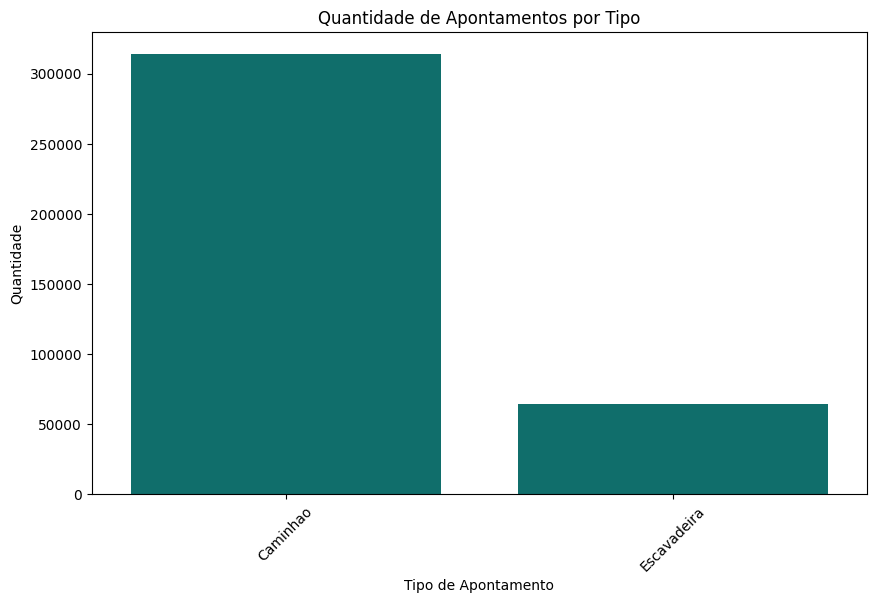

In [73]:
plt.figure(figsize=(10, 6))
# Cria uma nova figura para o gráfico com tamanho de 10 polegadas de largura e 6 de altura

sns.countplot(data=df_apontamentos, x='Tipo', order=df_apontamentos['Tipo'].value_counts().index,
              color= '#007E7A')
# Cria um gráfico de barras contando as ocorrências de cada valor da coluna 'Tipo'
# - data: o DataFrame com os dados
# - x: a coluna usada no eixo horizontal
# - order: ordena as barras do valor mais frequente para o menos frequente

plt.title('Quantidade de Apontamentos por Tipo')
# Define o título exibido no topo do gráfico

plt.xlabel('Tipo de Apontamento')
# Define o rótulo do eixo X (horizontal)

plt.ylabel('Quantidade')
# Define o rótulo do eixo Y (vertical)

plt.xticks(rotation=45)
# Rotaciona os rótulos do eixo X em 45° para evitar sobreposição quando os textos são longos

plt.show()
# Renderiza e exibe o gráfico na tela

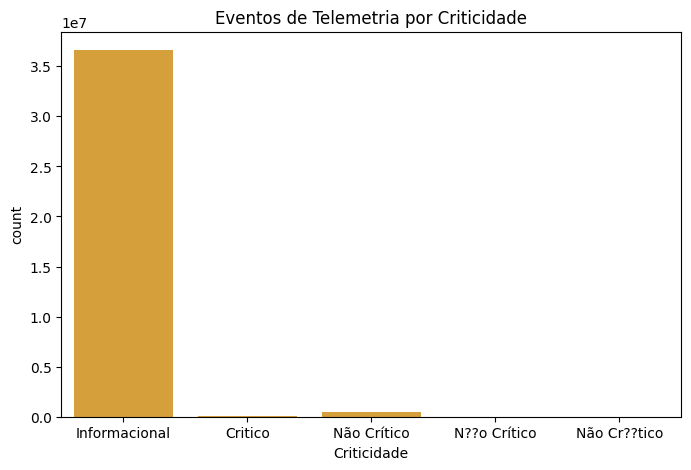

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_telemetria_total, x='Criticidade', color='#EEA722')
plt.title('Eventos de Telemetria por Criticidade')
plt.show()

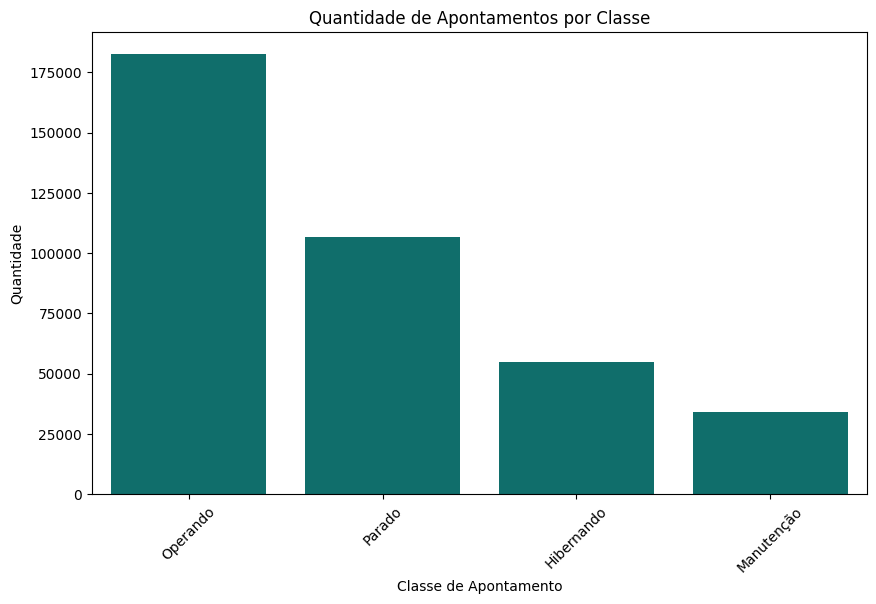

In [81]:
plt.figure(figsize=(10, 6))
# Cria uma nova figura para o gráfico com tamanho de 10 polegadas de largura e 6 de altura

sns.countplot(data=df_apontamentos, x='Classe', order=df_apontamentos['Classe'].value_counts().index,
              color= '#007E7A')
# Cria um gráfico de barras contando as ocorrências de cada valor da coluna 'Classe'
# - data: o DataFrame com os dados
# - x: a coluna usada no eixo horizontal
# - order: ordena as barras do valor mais frequente para o menos frequente

plt.title('Quantidade de Apontamentos por Classe')
# Define o título exibido no topo do gráfico

plt.xlabel('Classe de Apontamento')
# Define o rótulo do eixo X (horizontal)

plt.ylabel('Quantidade')
# Define o rótulo do eixo Y (vertical)

plt.xticks(rotation=45)
# Rotaciona os rótulos do eixo X em 45° para evitar sobreposição quando os textos são longos

plt.show()
# Renderiza e exibe o gráfico na tela

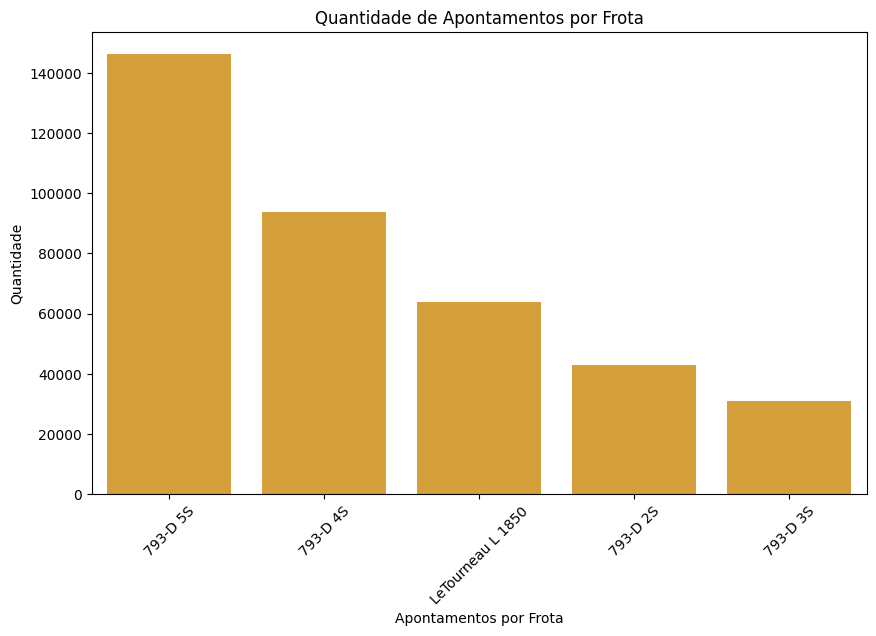

In [83]:
plt.figure(figsize=(10, 6))
# Cria uma nova figura para o gráfico com tamanho de 10 polegadas de largura e 6 de altura

sns.countplot(data=df_apontamentos, x='Frota', order=df_apontamentos['Frota'].value_counts().index,
              color= '#EEA722')
# Cria um gráfico de barras contando as ocorrências de cada valor da coluna 'Frota'
# - data: o DataFrame com os dados
# - x: a coluna usada no eixo horizontal
# - order: ordena as barras do valor mais frequente para o menos frequente

plt.title('Quantidade de Apontamentos por Frota')
# Define o título exibido no topo do gráfico

plt.xlabel('Apontamentos por Frota')
# Define o rótulo do eixo X (horizontal)

plt.ylabel('Quantidade')
# Define o rótulo do eixo Y (vertical)

plt.xticks(rotation=45)
# Rotaciona os rótulos do eixo X em 45° para evitar sobreposição quando os textos são longos

plt.show()
# Renderiza e exibe o gráfico na tela